In [1]:
import os
import pandas as pd
import hds
from plt_rcs import *

In [2]:
os.chdir('../data')

In [3]:
[file for file in os.listdir() if '용선' in file]

['용선품질_Si-S_예측.csv', '용선품질_Si-S_예측_전처리.pkl']

In [36]:
df = pd.read_pickle('용선품질_Si-S_예측_전처리.pkl')

In [37]:
drop_cols = ['노정압력_상부(kPa)', '노정압력_하부(kPa)', '용선온도(℃)', '슬래그염기도(CaO-SiO2)', '출선량(t/h)', '풍구온도_구간']                                                                           
df = df.drop(columns=drop_cols)

In [38]:
set(df[df['용선온도_lag24'].isna()].index) == set(df[df['슬래그염기도_lag24'].isna()].index) # True
set(df[df['용선온도_lag1'].isna()].index) == set(df[df['슬래그염기도_lag1'].isna()].index) # True
set(df[df['용선온도_lag1'].isna()].index) <= set(df[df['용선온도_lag24'].isna()].index) # True
# lag로 인한 결측값 제거
df = df.dropna(subset=['용선온도_lag24'])

In [39]:
df.head()

,측정일시,Heat_No,고로번호,풍구온도(℃),풍량(Nm3/min),장입코크스비(kg/t-pig),장입광석비(t/t-pig),고로내부온도_중단(℃),Si 실측(%),S 실측(%),노정압력차(kPa),용선온도_lag1,용선온도_lag24,슬래그염기도_lag1,슬래그염기도_lag24
24,2024-01-01 06:00:00,H24002,1,1144,5812,297.8,1.695,1465,0.487,0.0242,13.8,1491.0,1483.0,1.169,1.214
25,2024-01-01 06:15:00,H24002,1,1157,5804,307.9,1.674,1475,0.403,0.0219,13.7,1494.0,1502.0,1.173,1.239
26,2024-01-01 06:30:00,H24002,1,1130,5665,308.5,1.697,1501,0.486,0.0276,14.6,1508.0,1503.0,1.213,1.245
27,2024-01-01 06:45:00,H24002,1,1120,5657,301.1,1.724,1454,0.393,0.0282,15.7,1467.0,1499.0,1.163,1.161
28,2024-01-01 07:00:00,H24002,1,1139,6008,329.1,1.702,1466,0.439,0.0243,16.6,1485.0,1494.0,1.149,1.185


In [43]:
df_model = df.copy()

df_model = df_model.drop(columns = [
    'Heat_No',
    '측정일시',
    '고로번호'
])

# df_model = pd.get_dummies(df_model, columns = ['풍구온도_구간'], drop_first = True)

In [44]:
y_Si = df_model['Si 실측(%)']
y_S = df_model['S 실측(%)']
X = df_model.drop(columns = ['Si 실측(%)', 'S 실측(%)'])

## Si 예측

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_Si_train, y_Si_test = train_test_split(
    X, y_Si, 
    test_size = 0.2,
    shuffle = False)

# Si 기준으로 나눠진 인덱스 그대로 사용
y_S_train = y_S.loc[y_Si_train.index]
y_S_test = y_S.loc[y_Si_test.index]

model = RandomForestRegressor(
    n_estimators = 200,
    max_depth = 10,
    random_state = 42
)

model.fit(X_train, y_Si_train)
pred_Si = model.predict(X_test)
print('MAE:', mean_absolute_error(y_Si_test, pred_Si))

MAE: 0.0319033227533218


In [46]:
importance = pd.Series(model.feature_importances_, index = X.columns)
print(importance.sort_values(ascending = False))

풍구온도(℃)             0.466507
풍량(Nm3/min)         0.079514
고로내부온도_중단(℃)        0.062092
슬래그염기도_lag24        0.061046
용선온도_lag24          0.057821
장입광석비(t/t-pig)      0.056816
용선온도_lag1           0.056806
장입코크스비(kg/t-pig)    0.056704
슬래그염기도_lag1         0.052963
노정압력차(kPa)          0.049730
dtype: float64


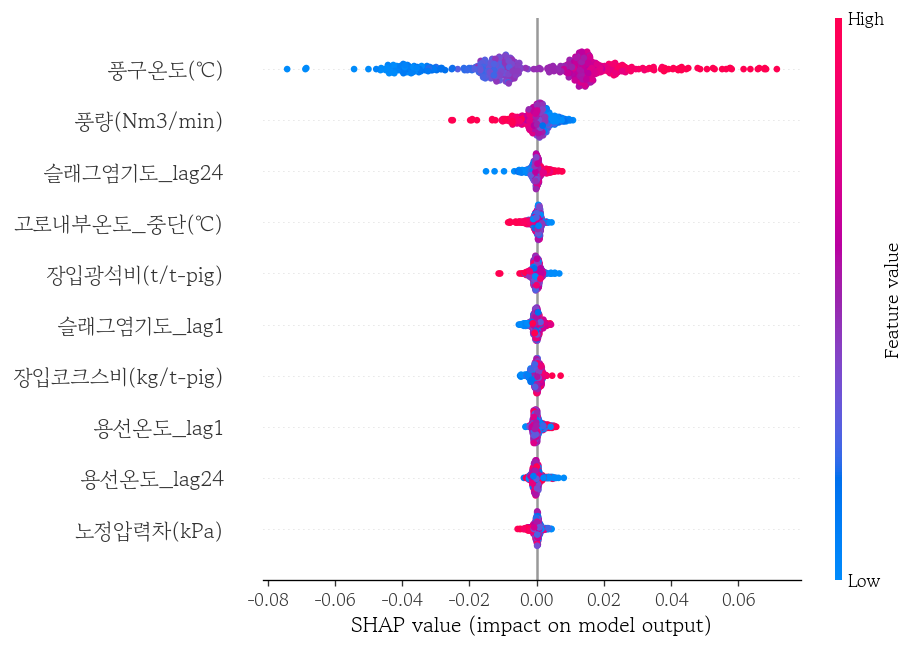

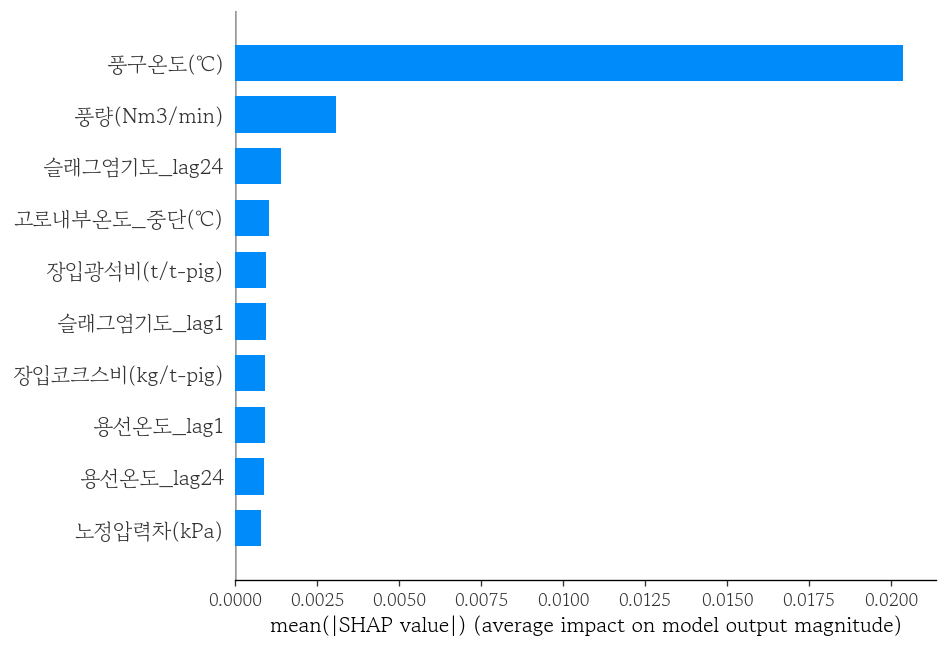

In [48]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

## S 예측

In [49]:
model.fit(X_train, y_S_train)
pred_S = model.predict(X_test)
print('MAE:', mean_absolute_error(y_S_test, pred_S))

MAE: 0.003575483083456053


In [50]:
importance = pd.Series(model.feature_importances_, index = X.columns)
print(importance.sort_values(ascending = False))

장입광석비(t/t-pig)      0.118602
풍량(Nm3/min)         0.113833
장입코크스비(kg/t-pig)    0.110473
풍구온도(℃)             0.110345
용선온도_lag24          0.098594
슬래그염기도_lag24        0.095639
슬래그염기도_lag1         0.093311
고로내부온도_중단(℃)        0.088612
용선온도_lag1           0.086278
노정압력차(kPa)          0.084312
dtype: float64


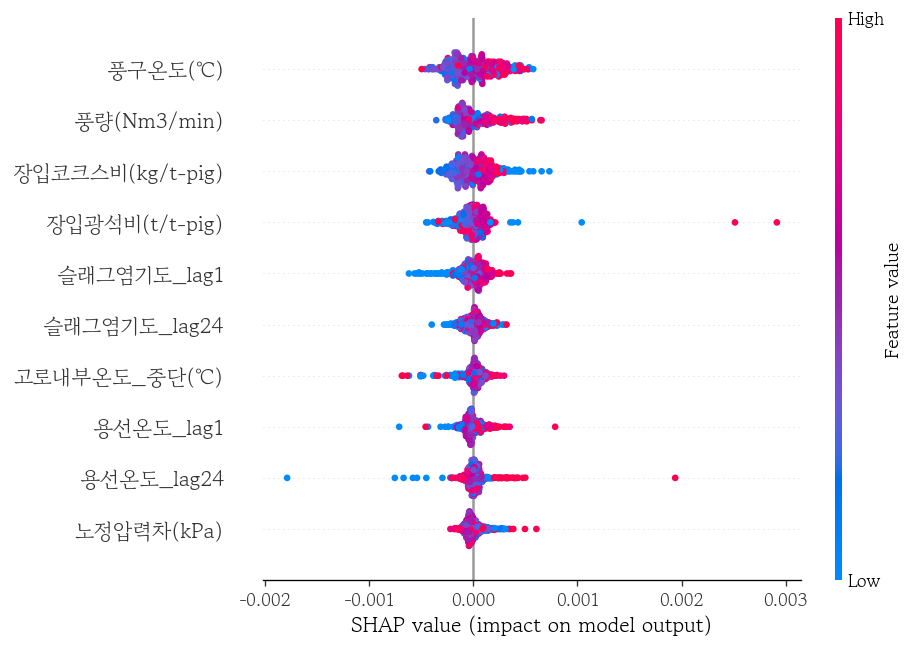

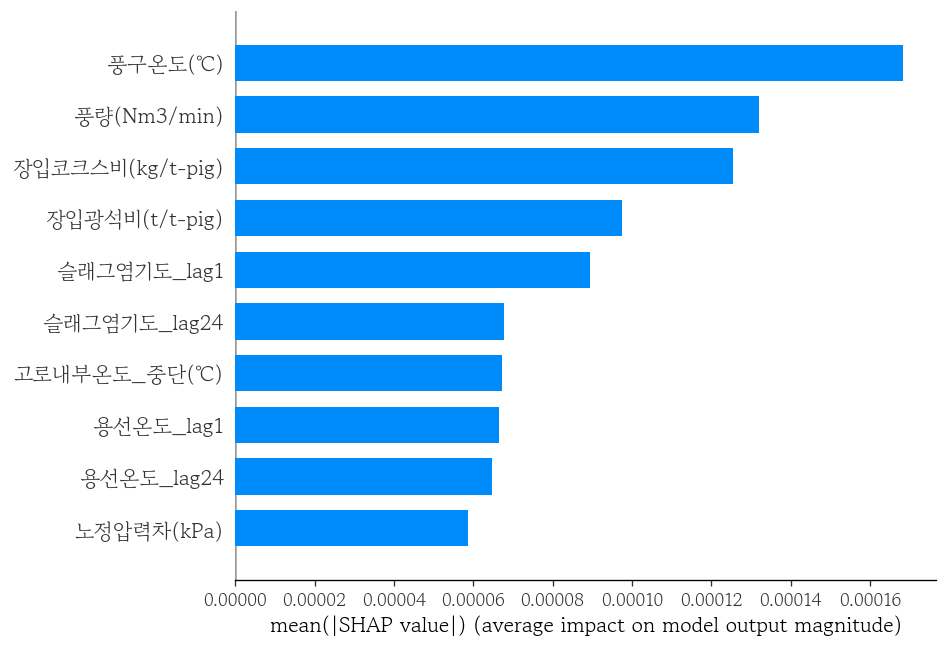

In [51]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

R2 Score: 0.1919278906507248


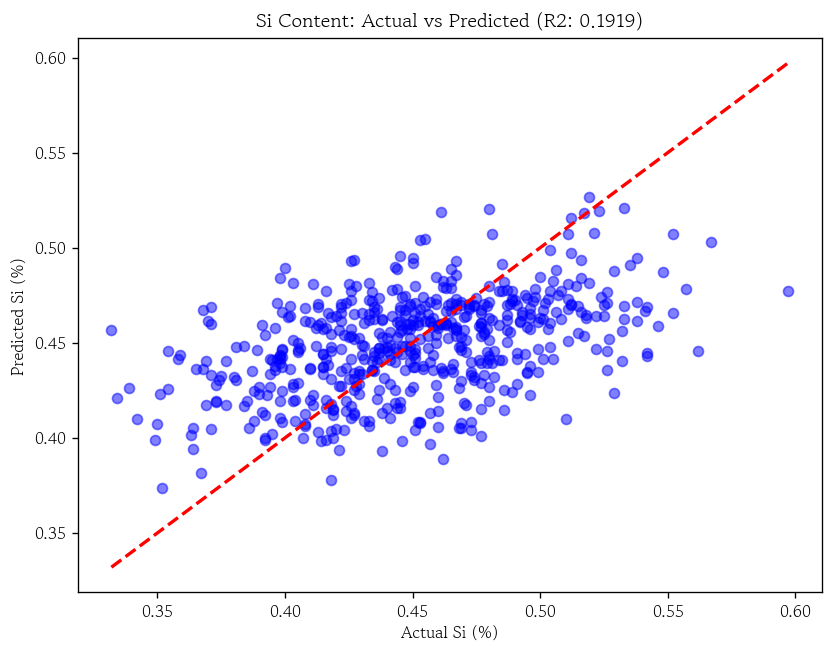

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# 1. R2 계산
r2 = r2_score(y_Si_test, pred_Si)
print(f'R2 Score: {r2}')

# 2. 시각화
plt.figure(figsize=(8, 6))
plt.scatter(y_Si_test, pred_Si, alpha=0.5, color='blue')
plt.plot([y_Si_test.min(), y_Si_test.max()], [y_Si_test.min(), y_Si_test.max()], 'r--', lw=2)
plt.xlabel('Actual Si (%)')
plt.ylabel('Predicted Si (%)')
plt.title(f'Si Content: Actual vs Predicted (R2: {r2:.4f})')
plt.show()

R2 Score: -0.013718847495369113


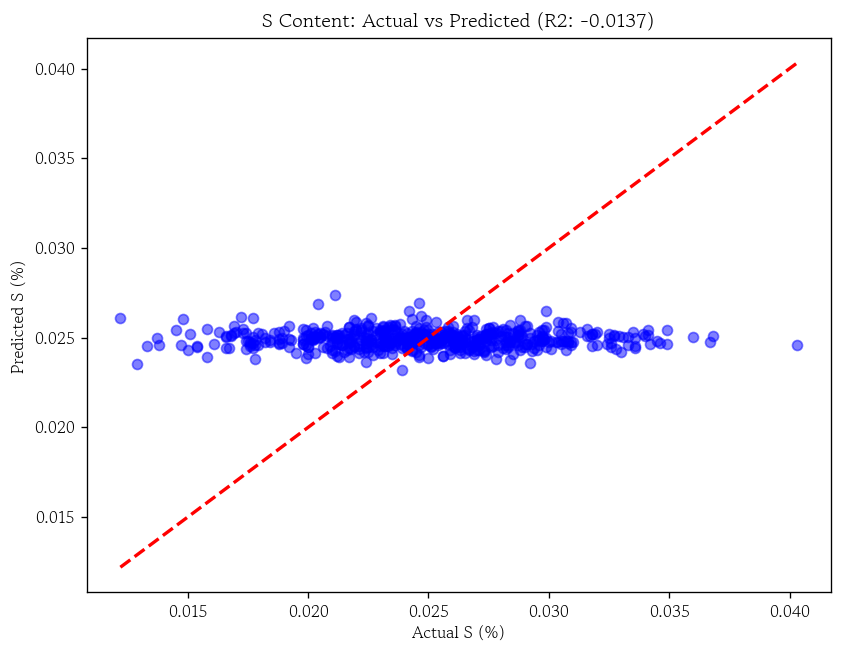

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# 1. R2 계산
r2 = r2_score(y_S_test, pred_S)
print(f'R2 Score: {r2}')

# 2. 시각화
plt.figure(figsize=(8, 6))
plt.scatter(y_S_test, pred_S, alpha=0.5, color='blue')
plt.plot([y_S_test.min(), y_S_test.max()], [y_S_test.min(), y_S_test.max()], 'r--', lw=2)
plt.xlabel('Actual S (%)')
plt.ylabel('Predicted S (%)')
plt.title(f'S Content: Actual vs Predicted (R2: {r2:.4f})')
plt.show()